In [1]:
# ================= INSTALL =================
!pip install -U imbalanced-learn xgboost

# ================= IMPORTS =================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
sns.set(style="whitegrid")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 8.8 MB/s eta 0:00:00
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.1.3
    Uninstalling xgboost-3.1.3:
      Successfully uninstalled xgboost-3.1.3


In [2]:
# ================= CELL 1: LOAD DATA + TARGET CREATION =================
import pandas as pd
import numpy as np

df = pd.read_excel("/content/multiclasss model.xlsx")
df.columns = df.columns.str.strip().str.lower()

# ================= HANDLE MISSING =================
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(exclude=np.number).columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna("unknown")

# ================= PRE-DISPATCH FEATURES =================
df["sla_time_hours"] = np.abs(df["time_buffer_hours"]) + df["distance_km"] / 40
df["order_density"] = df["order_volume"] / (df["distance_km"] + 1)
df["cost_intensity"] = df["delivery_cost"] / (df["order_volume"] + 1)

# ================= POST-DISPATCH FEATURES =================
df["traffic_pressure"] = df["traffic_index"] * df["hub_dwell_minutes"]
df["reliability_risk"] = df["driver_delay_rate"] * (1 - df["vehicle_reliability"])
df["distance_cost_interaction"] = df["distance_km"] * df["delivery_cost"]

# ================= STAGE TARGETS =================
tb = df["time_buffer_hours"]

# Stage-1: On-time vs Delayed
df["stage1_target"] = np.where(tb < 0, 0, 1)   # 0=on_time, 1=delayed

# Stage-2: Only for delayed
df["stage2_target"] = np.where(
    tb <= 3, 0, 1   # 0=at_risk, 1=delayed
)

# ================= DROP LEAKAGE =================
df.drop(columns=[
    "time_buffer_hours",
    "delivery_time_hours",
    "expected_time_hours",
    "actual_delivery_timestamp",
    "expected_delivery_timestamp",
    "delivery_status",
    "delivery_id"
], errors="ignore", inplace=True)

print("Stage-1 distribution:")
print(pd.Series(df["stage1_target"]).value_counts(normalize=True))

print("\nStage-2 distribution (only delayed):")
print(pd.Series(df.loc[df.stage1_target==1, "stage2_target"]).value_counts(normalize=True))

display(df.head())
print("Final shape:", df.shape)

Stage-1 distribution:
stage1_target
1    0.6116
0    0.3884
Name: proportion, dtype: float64

Stage-2 distribution (only delayed):
stage2_target
0    0.670242
1    0.329758
Name: proportion, dtype: float64


,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,order_volume,delivery_cost,traffic_index,...,driver_delay_rate,vehicle_reliability,sla_time_hours,order_density,cost_intensity,traffic_pressure,reliability_risk,distance_cost_interaction,stage1_target,stage2_target
0,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,1632.7206,0.599343,...,0.302747,0.872779,8.425000,0.157584,34.043382,11.641845,0.038516,484918.0182,0,0
1,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,640.1700,0.472347,...,0.272652,0.889788,4.886114,0.523068,13.229386,8.255707,0.030050,57359.2320,1,0
2,shadowfax,groceries,truck,two day,east,rainy,151.4,26.89,1448.1700,0.629538,...,0.222265,0.900831,4.785000,0.176444,51.924346,8.017650,0.022042,219252.9380,0,0
3,dhl,electronics,ev van,same day,east,cold,269.7,12.69,1486.5700,0.804606,...,0.727396,0.915100,7.742500,0.046878,108.588020,13.922578,0.061756,400927.9290,0,0
4,dhl,clothing,van,two day,north,foggy,256.7,37.02,1394.5600,0.453169,...,0.106237,0.862950,11.317823,0.143655,36.679642,10.776185,0.014560,357983.5520,1,1


Final shape: (25000, 21)


In [3]:
# ================= CELL 2: SPLITTING & ENCODING =================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

features = df.drop(columns=["stage1_target", "stage2_target"])

X = features
y1 = df["stage1_target"]

# ---------- Stage-1 split ----------
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X, y1, test_size=0.30, random_state=42, stratify=y1
)

num_cols = X1_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X1_train.select_dtypes(exclude=np.number).columns.tolist()

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

X1_train_cat = encoder.fit_transform(X1_train[cat_cols])
X1_test_cat  = encoder.transform(X1_test[cat_cols])

X1_train_final = np.hstack([X1_train[num_cols].values, X1_train_cat])
X1_test_final  = np.hstack([X1_test[num_cols].values, X1_test_cat])

# ---------- Stage-2 data ----------
mask_train = y1_train == 1
mask_test  = y1_test == 1

X2_train_final = X1_train_final[mask_train]
X2_test_final  = X1_test_final[mask_test]

y2_train = df.loc[X1_train.index[mask_train], "stage2_target"]
y2_test  = df.loc[X1_test.index[mask_test], "stage2_target"]

print("Stage-1 shapes:", X1_train_final.shape, X1_test_final.shape)
print("Stage-2 shapes:", X2_train_final.shape, X2_test_final.shape)

Stage-1 shapes: (17500, 58) (7500, 58)
Stage-2 shapes: (10703, 58) (4587, 58)


In [4]:
# ================= CELL 3: MODELLING =================
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# =================================================
# STAGE-1 MODEL (ON-TIME vs DELAYED)
# =================================================

stage1_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=10,
    gamma=1.0,
    scale_pos_weight=2.8,   # key for recall
    eval_metric="logloss",
    random_state=42
)

stage1_model.fit(X1_train_final, y1_train)

# tuned threshold
y1_probs = stage1_model.predict_proba(X1_test_final)[:, 1]
y1_pred = (y1_probs > 0.42).astype(int)

print("\n[STAGE-1] On-Time vs Delayed")
print("Accuracy:", accuracy_score(y1_test, y1_pred))
print(classification_report(y1_test, y1_pred, target_names=["on_time", "delayed"]))
# ================= CELL 3 (REPLACEMENT): STAGE-2 MODELLING =================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb
import numpy as np

# --------------------------------------------------
# STAGE-2 RANDOM FOREST (STRONG, NOT UNDERFIT)
# --------------------------------------------------
rf_stage2 = RandomForestClassifier(
    n_estimators=650,          # ↑ more trees
    max_depth=18,              # ↑ capture interactions
    min_samples_leaf=12,       # ↓ allow sharper splits
    min_samples_split=20,
    max_features="sqrt",
    class_weight={0:1.0, 1:2.2},   # ↑ delayed is expensive
    random_state=42,
    n_jobs=-1
)

rf_stage2.fit(X2_train_final, y2_train)

y2_pred_rf = rf_stage2.predict(X2_test_final)
rf_acc = accuracy_score(y2_test, y2_pred_rf)

print("\n[Stage-2] At-Risk vs Delayed (Random Forest)")
print(classification_report(y2_test, y2_pred_rf, target_names=["at_risk", "delayed"]))
print("RF Stage-2 Accuracy:", round(rf_acc,4))


from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

#from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# ================= STAGE-2 XGBOOST (CONTROLLED STRENGTH) =================

xgb_stage2 = XGBClassifier(
    # ---- Softer model ----
    n_estimators=220,          # ↓ fewer trees
    learning_rate=0.045,
    max_depth=3,               # ↓ shallower trees

    # ---- Strong regularization ----
    min_child_weight=35,       # ↑ prevents small memorizing splits
    gamma=2.5,                 # ↑ penalizes aggressive splits
    subsample=0.65,            # ↑ randomness
    colsample_bytree=0.65,

    reg_alpha=4.0,
    reg_lambda=8.0,

    # ---- Class imbalance ----
    scale_pos_weight=(
        y2_train.value_counts()[0] / y2_train.value_counts()[1]
    ),

    # ---- Monotonic constraints ----
    monotone_constraints="(1,1,1,1,1,-1,-1)",

    # ---- Objective ----
    objective="binary:logistic",
    eval_metric="logloss",

    random_state=42,
    n_jobs=-1
)

# Train
xgb_stage2.fit(X2_train_final, y2_train)

# Predict (default threshold = 0.5)
y2_pred_xgb = xgb_stage2.predict(X2_test_final)

# Accuracy
xgb_acc = accuracy_score(y2_test, y2_pred_xgb)

print("\n[Stage-2] At-Risk vs Delayed (XGBoost – Regularized)")
print(f"Accuracy: {xgb_acc:.4f}\n")

print(classification_report(
    y2_test,
    y2_pred_xgb,
    target_names=["at_risk", "delayed"]
))

print("\n========== FINAL STAGE-2 SUMMARY ==========")
print(f"Stage-2 Accuracy (RF)  : {rf_acc:.4f}")
print(f"Stage-2 Accuracy (XGB) : {xgb_acc:.4f}")


[STAGE-1] On-Time vs Delayed
Accuracy: 0.9022666666666667
              precision    recall  f1-score   support

     on_time       0.93      0.80      0.86      2913
     delayed       0.89      0.96      0.92      4587

    accuracy                           0.90      7500
   macro avg       0.91      0.88      0.89      7500
weighted avg       0.90      0.90      0.90      7500


[Stage-2] At-Risk vs Delayed (Random Forest)
              precision    recall  f1-score   support

     at_risk       0.97      0.93      0.95      3055
     delayed       0.87      0.94      0.91      1532

    accuracy                           0.93      4587
   macro avg       0.92      0.94      0.93      4587
weighted avg       0.94      0.93      0.94      4587

RF Stage-2 Accuracy: 0.9348

[Stage-2] At-Risk vs Delayed (XGBoost – Regularized)
Accuracy: 0.9472

              precision    recall  f1-score   support

     at_risk       0.98      0.94      0.96      3055
     delayed       0.89      0.9

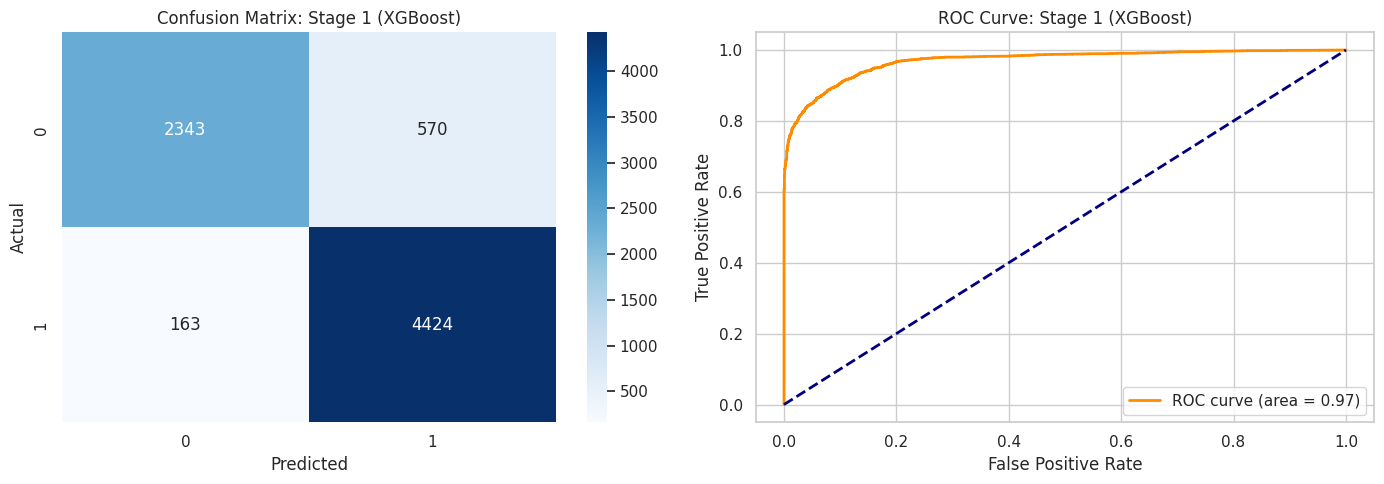

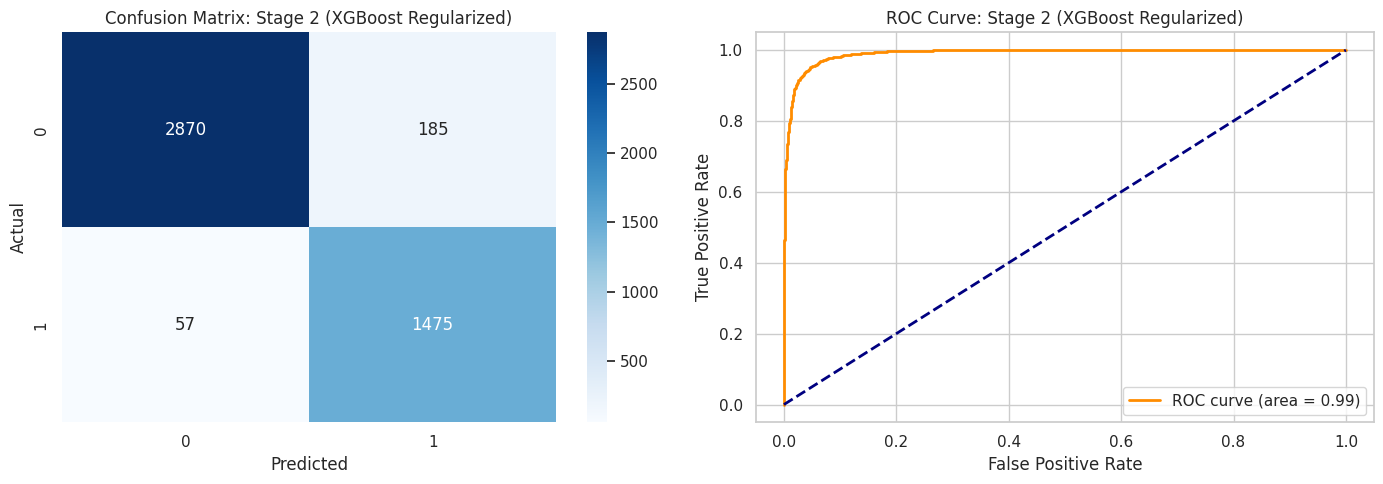

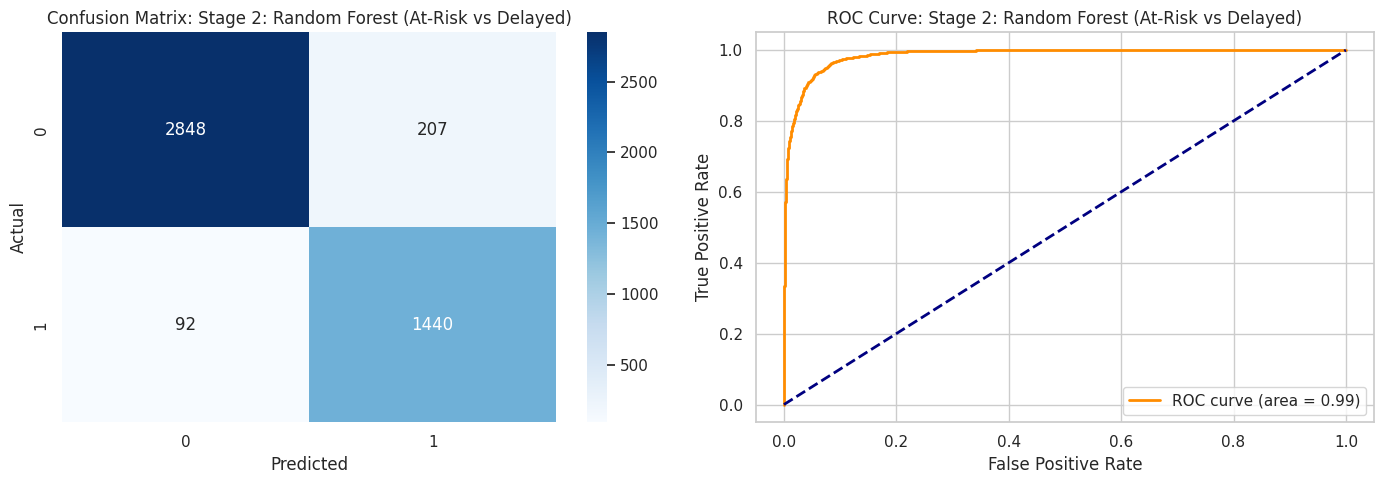

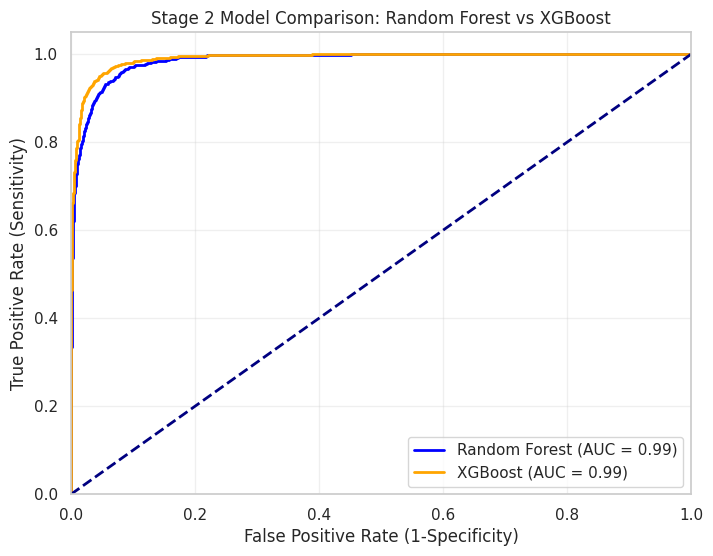


Generating SHAP Summary Plot for Stage 1...


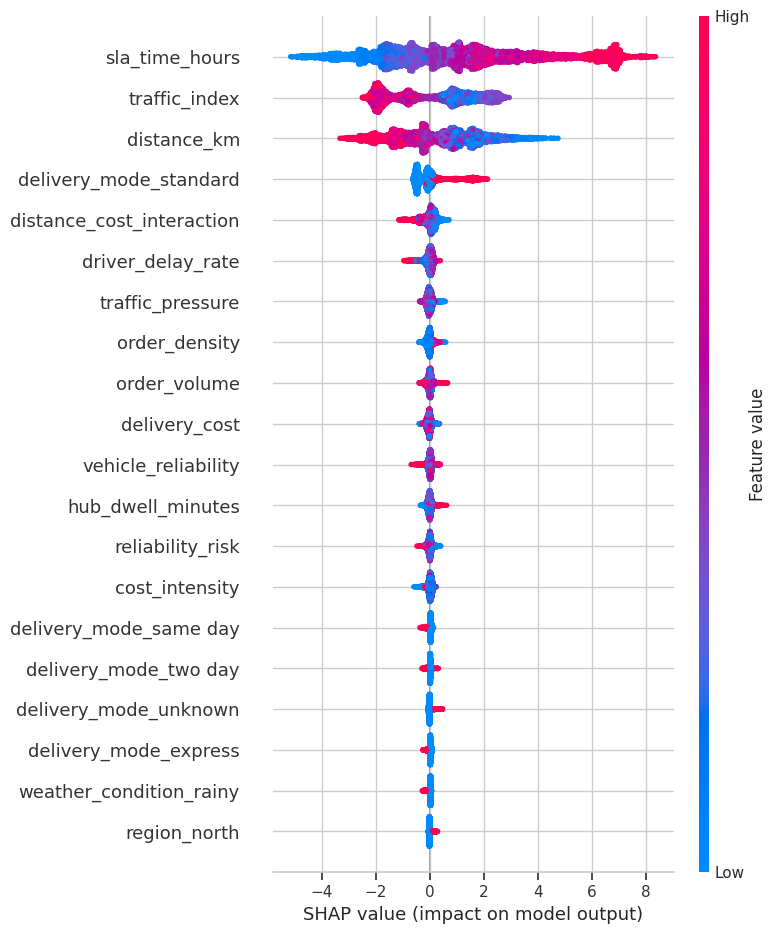

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
import shap

# --- Function for Confusion Matrix & ROC ---
def plot_evaluation(y_true, y_probs, y_pred, title):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f'Confusion Matrix: {title}')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    ax[1].set_title(f'ROC Curve: {title}')
    ax[1].set_xlabel('False Positive Rate')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].legend(loc="lower right")
    plt.tight_layout()
    plt.show()

# --- EXECUTE PLOTS ---

# Stage 1: On-Time vs Delayed
plot_evaluation(y1_test, y1_probs, y1_pred, "Stage 1 (XGBoost)")

# Stage 2: At-Risk vs Delayed (Using the XGBoost version)
y2_probs_xgb = xgb_stage2.predict_proba(X2_test_final)[:, 1]
plot_evaluation(y2_test, y2_probs_xgb, y2_pred_xgb, "Stage 2 (XGBoost Regularized)")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
# ==========================================================
# EVALUATION FOR RANDOM FOREST (STAGE 2)
# ==========================================================

# 1. Get predicted probabilities for the positive class (Delayed)
# This is required for the ROC Curve calculation
y2_probs_rf = rf_stage2.predict_proba(X2_test_final)[:, 1]

# 2. Get the hard predictions (0 or 1)
# (Already defined as y2_pred_rf in your script, but re-confirming here)
y2_pred_rf = rf_stage2.predict(X2_test_final)

# 3. Use your custom evaluation function to plot both visuals
plot_evaluation(
    y2_test,
    y2_probs_rf,
    y2_pred_rf,
    "Stage 2: Random Forest (At-Risk vs Delayed)"
)
# ==========================================================
# STAGE 2: COMPARISON CURVE (RF vs XGBoost)
# ==========================================================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# 1. Get probabilities for both models
y2_probs_rf = rf_stage2.predict_proba(X2_test_final)[:, 1]
y2_probs_xgb = xgb_stage2.predict_proba(X2_test_final)[:, 1]

# 2. Calculate ROC metrics for Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y2_test, y2_probs_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# 3. Calculate ROC metrics for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y2_test, y2_probs_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# 4. Plotting the "Umbrella" Comparison
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot(fpr_xgb, tpr_xgb, color='orange', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1-Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Stage 2 Model Comparison: Random Forest vs XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
# --- SHAP VALUES (XGBoost Stage 1) ---
print("\nGenerating SHAP Summary Plot for Stage 1...")
explainer = shap.TreeExplainer(stage1_model)
shap_values = explainer.shap_values(X1_test_final)

# Mapping feature names back (Numerical + OneHot encoded)
feature_names = num_cols + list(encoder.get_feature_names_out(cat_cols))
shap.summary_plot(shap_values, X1_test_final, feature_names=feature_names)

In [17]:
import statsmodels.api as sm

# Adding a constant for the intercept
X_stat = sm.add_constant(X1_train_final)
# Fitting the model
logit_mod = sm.Logit(y1_train, X_stat)
logit_res = logit_mod.fit(disp=0)

print("--- Feature Statistical Significance (P-Values) ---")
# Displaying p-values for the first 10 features as a sample
print(logit_res.pvalues[:10])

--- Feature Statistical Significance (P-Values) ---
const     9.999972e-01
x1       7.249430e-234
x2        6.309309e-02
x3        1.986727e-01
x4       9.638591e-180
x5        1.167992e-01
x6        7.398473e-01
x7        2.439464e-01
x8        0.000000e+00
x9        2.009518e-13
dtype: float64
